# EMG Gesture Classification — v3: 1D CNN on raw windows

**What changed from v2:**
- 30 sessions total (10 per class) — double the data
- Model input: raw 50-sample filtered window instead of 6 hand-crafted features
- Architecture: 1D CNN — learns its own feature extraction from waveform shape
- Cross-session test split — held-out sessions never seen during training
- Leave-one-session-out validation to estimate real-world accuracy

**Why 1D CNN over features?**
The v2 analysis showed that hand-crafted features (RMS, MAV, VAR etc.) collapse
the 50-sample waveform into single numbers, throwing away the temporal shape.
A quick pinch rises and falls faster than a fist. A CNN can learn this directly
from the waveform — no manual feature engineering needed.

## Step 1 — Install and import

In [ ]:
!pip install -q torchinfo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchinfo import summary
import warnings, os, zipfile
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

Device: cuda
GPU   : Tesla T4


## Step 2 — Configuration

In [ ]:
# ── Hardware ──────────────────────────────────────────────────────────────────
FS          = 250           # Confirmed: Chords firmware SAMP_RATE 250.0
NYQUIST     = FS / 2        # 125 Hz

# ── Filter ────────────────────────────────────────────────────────────────────
# 2nd order Butterworth bandpass → 4th order IIR (5 coefficients)
# FIXED vs v1: v1 had a variable-naming bug that wrote wrong values into FILTER_B
FILTER_LOW  = 20            # Hz — removes motion artifact and cable noise
FILTER_HIGH = 120           # Hz — removes noise above EMG spectrum
b_filt, a_filt = butter(2, [FILTER_LOW/NYQUIST, FILTER_HIGH/NYQUIST], btype='band')
print('FILTER_B:', b_filt)
print('FILTER_A:', a_filt)

# ── Windowing ─────────────────────────────────────────────────────────────────
# 200ms window × 250Hz = 50 samples
# 50% overlap → new prediction every 100ms
WINDOW_SIZE = 50
STEP_SIZE   = 25

# ── Labeling ──────────────────────────────────────────────────────────────────
# Windows with RMS above threshold in a gesture file → labeled as gesture
# Below threshold → labeled as rest (captures inter-rep gaps cleanly)
RMS_THRESHOLD = 0.020

# ── Classes ───────────────────────────────────────────────────────────────────
CLASSES     = ['rest', 'quick_pinch', 'quick_fist']
NUM_CLASSES = len(CLASSES)
label_to_idx = {c: i for i, c in enumerate(CLASSES)}
idx_to_label = {i: c for c, i in label_to_idx.items()}

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS      = 80
BATCH_SIZE  = 128
LR          = 1e-3
SEED        = 42
# Sessions 9 and 10 are held out for testing — never seen during training
# This simulates a new recording day, which is the hardest real-world test
TEST_SESSIONS = [9, 10]

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'\nWindow : {WINDOW_SIZE} samples = {WINDOW_SIZE*1000//FS}ms')
print(f'Step   : {STEP_SIZE} samples = {STEP_SIZE*1000//FS}ms')
print(f'Test sessions held out: {TEST_SESSIONS}')

FILTER_B: [ 0.63894553  0.         -1.27789105  0.          0.63894553]
FILTER_A: [ 1.          0.51967834 -1.04376861 -0.19245083  0.4128016 ]

Window : 50 samples = 200ms
Step   : 25 samples = 100ms
Test sessions held out: [9, 10]


## Step 3 — Upload all 30 CSV files

Upload all files from sessions 1–10:
- `rest1.csv` ... `rest10.csv`
- `quick_pinch1.csv` ... `quick_pinch10.csv`
- `quick_fist1.csv` ... `quick_fist10.csv`

In [ ]:
from google.colab import files
print('Select all 30 CSV files...')
uploaded = files.upload()
print(f'Uploaded {len(uploaded)} files')

Select all 30 CSV files...


Saving quick_fist1.csv to quick_fist1.csv
Saving quick_fist2.csv to quick_fist2.csv
Saving quick_fist3.csv to quick_fist3.csv
Saving quick_fist4.csv to quick_fist4.csv
Saving quick_fist5.csv to quick_fist5.csv
Saving quick_fist6.csv to quick_fist6.csv
Saving quick_fist7.csv to quick_fist7.csv
Saving quick_fist8.csv to quick_fist8.csv
Saving quick_fist9.csv to quick_fist9.csv
Saving quick_fist10.csv to quick_fist10.csv
Saving quick_pinch1.csv to quick_pinch1.csv
Saving quick_pinch2.csv to quick_pinch2.csv
Saving quick_pinch3.csv to quick_pinch3.csv
Saving quick_pinch4.csv to quick_pinch4.csv
Saving quick_pinch5.csv to quick_pinch5.csv
Saving quick_pinch6.csv to quick_pinch6.csv
Saving quick_pinch7.csv to quick_pinch7.csv
Saving quick_pinch8.csv to quick_pinch8.csv
Saving quick_pinch9.csv to quick_pinch9.csv
Saving quick_pinch10.csv to quick_pinch10.csv
Saving rest1.csv to rest1.csv
Saving rest2.csv to rest2.csv
Saving rest3.csv to rest3.csv
Saving rest4.csv to rest4.csv
Saving rest5.csv

## Step 4 — Load, filter and segment all sessions

In [ ]:
def sliding_windows(signal, ws, ss):
    return [signal[i:i+ws] for i in range(0, len(signal) - ws + 1, ss)]

# Storage: raw windows (50 samples each), labels, session IDs
all_windows  = []
all_labels   = []
all_sessions = []

print(f'{'File':<22} {'Sessions':>4} {'Gesture wins':>13} {'Rest wins':>10}')
print('-' * 54)

for label in CLASSES:
    for session_id in range(1, 11):
        fname = f'{label}{session_id}.csv'
        try:
            df  = pd.read_csv(fname)
            sig = df['Channel1'].values.astype(np.float32)
        except FileNotFoundError:
            print(f'  MISSING: {fname}')
            continue

        # Apply bandpass filter
        filtered = filtfilt(b_filt, a_filt, sig).astype(np.float32)

        # Segment into overlapping windows
        windows = sliding_windows(filtered, WINDOW_SIZE, STEP_SIZE)
        g_count = r_count = 0

        for w in windows:
            w_arr = np.array(w, dtype=np.float32)
            rms   = np.sqrt(np.mean(w_arr**2))

            if label == 'rest' or rms <= RMS_THRESHOLD:
                lbl = 'rest'
                r_count += 1
            else:
                lbl = label
                g_count += 1

            all_windows.append(w_arr)
            all_labels.append(lbl)
            all_sessions.append(session_id)

        print(f'{fname:<22} {session_id:>4} {g_count:>13} {r_count:>10}')

all_windows  = np.array(all_windows,  dtype=np.float32)   # (N, 50)
all_labels   = np.array(all_labels)
all_sessions = np.array(all_sessions)
y_all        = np.array([label_to_idx[l] for l in all_labels], dtype=np.int64)

print(f'\nTotal windows : {len(all_windows)}')
unique, counts = np.unique(all_labels, return_counts=True)
print('Class distribution:')
for cls, cnt in zip(unique, counts):
    print(f'  {cls:<16}: {cnt:5d}  {chr(9608) * (cnt//50)}')

File                   Sessions  Gesture wins  Rest wins
------------------------------------------------------
rest1.csv                 1             0        219
rest2.csv                 2             0        199
rest3.csv                 3             0        199
rest4.csv                 4             0        219
rest5.csv                 5             0        219
rest6.csv                 6             0        219
rest7.csv                 7             0        219
rest8.csv                 8             0        219
rest9.csv                 9             0        199
rest10.csv               10             0        199
quick_pinch1.csv          1           117        142
quick_pinch2.csv          2           156        123
quick_pinch3.csv          3           151        128
quick_pinch4.csv          4           130        109
quick_pinch5.csv          5           129         90
quick_pinch6.csv          6           180         99
quick_pinch7.csv          7           15

## Step 5 — Visualise raw and filtered EMG for all sessions

Each column is one session (1–10). Each row is one class.
This view shows you at a glance whether signal quality is consistent
across all your recording sessions.

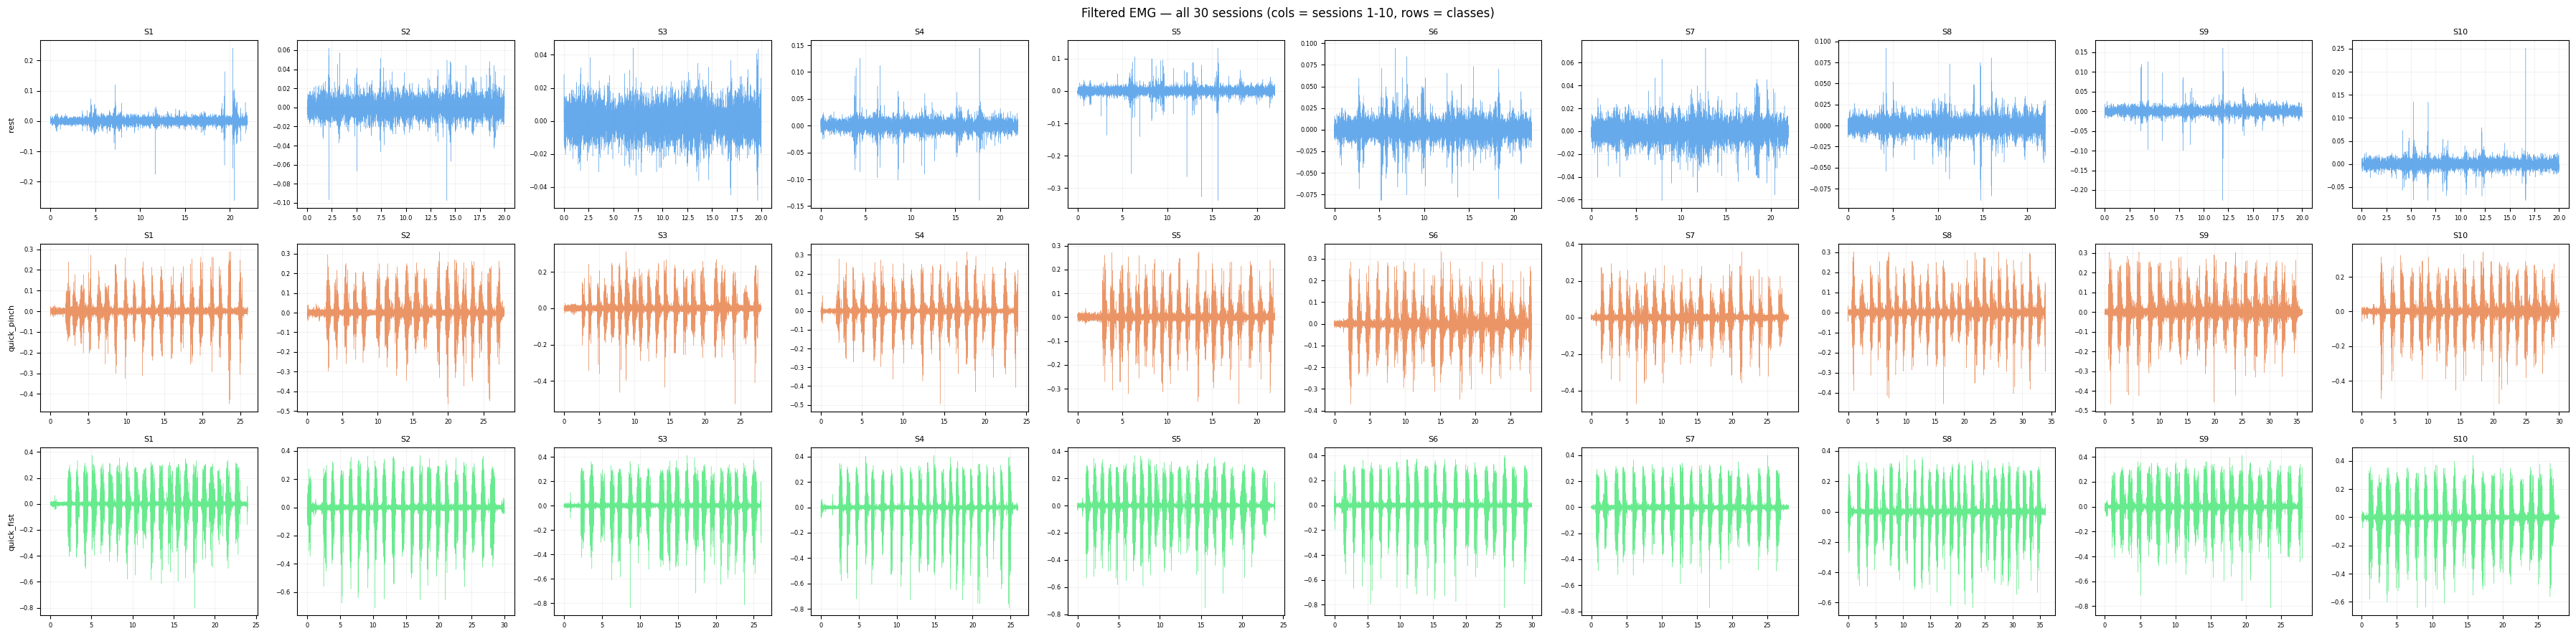

Sessions 9 and 10 are held out as the test set — the model never trains on them.


In [ ]:
palette = {'rest': '#4C9BE8', 'quick_pinch': '#E8834C', 'quick_fist': '#4CE87A'}

fig, axes = plt.subplots(3, 10, figsize=(36, 9))

for label in CLASSES:
    row = CLASSES.index(label)
    for session_id in range(1, 11):
        fname = f'{label}{session_id}.csv'
        col   = session_id - 1
        ax    = axes[row][col]
        try:
            df  = pd.read_csv(fname)
            sig = filtfilt(b_filt, a_filt, df['Channel1'].values.astype(float))
            t   = np.arange(len(sig)) / FS
            ax.plot(t, sig, color=palette[label], lw=0.3, alpha=0.85)
        except FileNotFoundError:
            ax.text(0.5, 0.5, 'missing', transform=ax.transAxes,
                    ha='center', va='center', fontsize=8, color='red')
        ax.set_title(f'S{session_id}', fontsize=8)
        ax.tick_params(labelsize=6)
        ax.grid(True, alpha=0.15)
        if col == 0: ax.set_ylabel(label, fontsize=8)

plt.suptitle('Filtered EMG — all 30 sessions (cols = sessions 1-10, rows = classes)', fontsize=12)
plt.tight_layout()
plt.savefig('all_sessions_v3.png', dpi=90, bbox_inches='tight')
plt.show()
print('Sessions 9 and 10 are held out as the test set — the model never trains on them.')

## Step 6 — Cross-session train/test split

**Why split by session, not by random window?**

If you split randomly, windows from the same recording session appear
in both train and test. The model memorises session-specific noise
and appears more accurate than it really is.

By holding out entire sessions (9 and 10), we test on data from
a completely different recording day — this is how the model will
behave on your arm tomorrow.

In [ ]:
test_mask  = np.isin(all_sessions, TEST_SESSIONS)
train_mask = ~test_mask

X_train = all_windows[train_mask]   # (N_train, 50)
y_train = y_all[train_mask]
X_test  = all_windows[test_mask]    # (N_test,  50)
y_test  = y_all[test_mask]

# Reshape for 1D CNN: (N, channels, length) = (N, 1, 50)
X_train_cnn = X_train[:, np.newaxis, :]   # (N_train, 1, 50)
X_test_cnn  = X_test[:,  np.newaxis, :]   # (N_test,  1, 50)

print(f'Train: {len(X_train)} windows from sessions 1-8')
print(f'Test : {len(X_test)}  windows from sessions 9-10 (never seen in training)')
print(f'CNN input shape: {X_train_cnn.shape}')
print()

print('Train class distribution:')
for i, cls in enumerate(CLASSES):
    count = np.sum(y_train == i)
    print(f'  {cls:<16}: {count}')
print()
print('Test class distribution:')
for i, cls in enumerate(CLASSES):
    count = np.sum(y_test == i)
    print(f'  {cls:<16}: {count}')

Train: 6116 windows from sessions 1-8
Test : 1614  windows from sessions 9-10 (never seen in training)
CNN input shape: (6116, 1, 50)

Train class distribution:
  rest            : 3624
  quick_pinch     : 1206
  quick_fist      : 1286

Test class distribution:
  rest            : 816
  quick_pinch     : 435
  quick_fist      : 363


## Step 7 — Visualise what the CNN actually sees

Each panel shows 20 randomly sampled windows from each class,
overlaid. This is literally what the network processes — 50 samples
of filtered EMG.

Notice:
- **rest**: flat, nearly zero signal
- **quick_pinch**: moderate amplitude burst
- **quick_fist**: higher amplitude burst, wider envelope

The CNN learns the subtle shape differences that features like RMS discard.

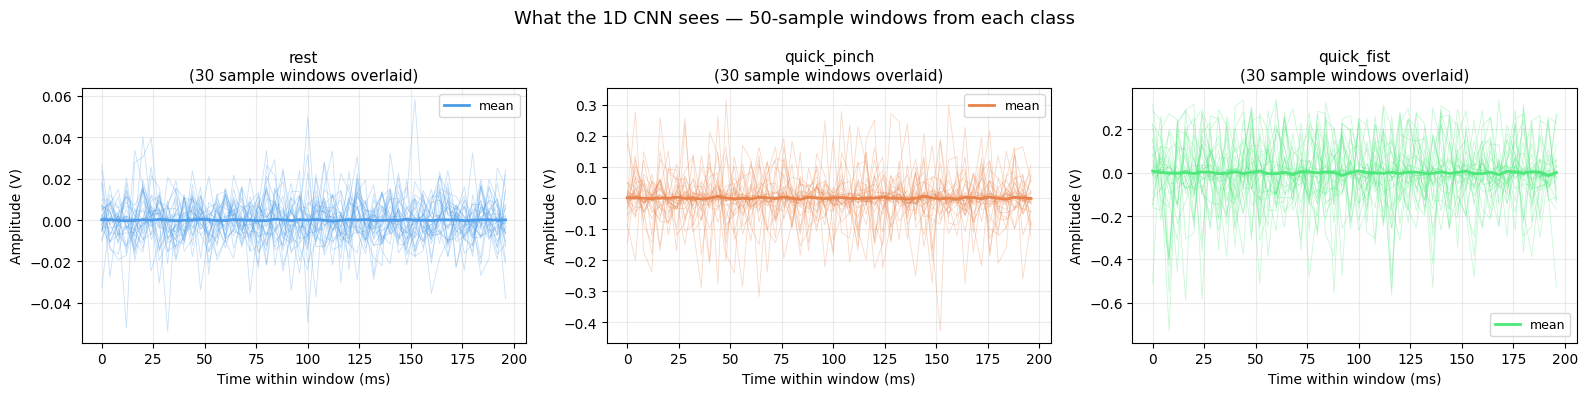

In [ ]:
np.random.seed(SEED)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
t = np.arange(WINDOW_SIZE) / FS * 1000   # in milliseconds

for col, label in enumerate(CLASSES):
    ax    = axes[col]
    cls_i = label_to_idx[label]
    mask  = y_train == cls_i
    idxs  = np.random.choice(np.where(mask)[0], size=min(30, mask.sum()), replace=False)
    color = list(palette.values())[col]

    for idx in idxs:
        ax.plot(t, X_train[idx], color=color, lw=0.6, alpha=0.3)

    # Mean envelope
    mean_win = X_train[mask].mean(axis=0)
    ax.plot(t, mean_win, color=color, lw=2.0, alpha=1.0, label='mean')

    ax.set_title(f'{label}\n(30 sample windows overlaid)', fontsize=11)
    ax.set_xlabel('Time within window (ms)')
    ax.set_ylabel('Amplitude (V)')
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9)

plt.suptitle('What the 1D CNN sees — 50-sample windows from each class', fontsize=13)
plt.tight_layout()
plt.savefig('cnn_input_windows.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 8 — Data augmentation

Same augmentation as v2 but applied to raw windows, not features:
- **Amplitude scaling** (±20%): simulates contraction strength variation
- **Gaussian noise** (1–5% of window std): simulates ADC noise

We augment only gesture windows (not rest), 4 variants each.

In [ ]:
def augment_window(window, n_aug=4):
    augmented = []
    for _ in range(n_aug):
        w = window.copy()
        w = w * np.random.uniform(0.80, 1.20)     # amplitude scale
        noise = np.random.randn(len(w)).astype(np.float32)
        noise_std = np.std(w) * np.random.uniform(0.01, 0.05)
        w = w + noise * noise_std
        augmented.append(w.astype(np.float32))
    return augmented

rest_idx  = label_to_idx['rest']
aug_X, aug_y = [], []

for i in range(len(X_train)):
    if y_train[i] != rest_idx:
        for aw in augment_window(X_train[i], n_aug=4):
            aug_X.append(aw)
            aug_y.append(y_train[i])

aug_X = np.array(aug_X, dtype=np.float32)
aug_y = np.array(aug_y, dtype=np.int64)

X_train_aug = np.vstack([X_train, aug_X])                    # (N_aug, 50)
y_train_aug = np.concatenate([y_train, aug_y])
X_train_aug_cnn = X_train_aug[:, np.newaxis, :]              # (N_aug, 1, 50)

print(f'Original training windows : {len(X_train)}')
print(f'Augmented windows added   : {len(aug_X)}')
print(f'Total training windows    : {len(X_train_aug)}')
print()
print('Class distribution after augmentation:')
for i, cls in enumerate(CLASSES):
    count = np.sum(y_train_aug == i)
    print(f'  {cls:<16}: {count}')

Original training windows : 6116
Augmented windows added   : 9968
Total training windows    : 16084

Class distribution after augmentation:
  rest            : 3624
  quick_pinch     : 6030
  quick_fist      : 6430


## Step 9 — Build the 1D CNN

**How does a 1D CNN work on EMG?**

A 1D convolution slides a small filter (kernel) across the time axis of the signal.
Each filter learns to detect a specific waveform pattern — an onset spike, a plateau,
a rapid oscillation. Multiple filters at different sizes capture patterns at
different timescales.

```
Input: (1, 50) — 50 samples of filtered EMG
  Conv1D(32 filters, kernel=5) → (32, 46) — detects 20ms patterns
  BatchNorm + ReLU + MaxPool(2) → (32, 23)
  Conv1D(64 filters, kernel=3) → (64, 21) — detects 12ms patterns
  BatchNorm + ReLU + MaxPool(2) → (64, 10)
  Conv1D(64 filters, kernel=3) → (64, 8)  — detects fine details
  BatchNorm + ReLU
  GlobalAvgPool → (64,)         — compress to fixed size
  Dropout(0.4)
  Linear(64 → 32) + ReLU
  Linear(32 → 3)  + Softmax     — 3 class probabilities
```

**GlobalAvgPool instead of Flatten:** averages each feature map to one number.
This makes the model robust to slight timing differences in when the gesture starts
within the window.

In [ ]:
class EMGConvNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: detect coarse patterns (20ms at 250Hz = 5 samples)
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),            # 50 → 25
            nn.Dropout(0.2),

            # Block 2: detect mid-scale patterns
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),            # 25 → 12
            nn.Dropout(0.2),

            # Block 3: detect fine details
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            # No pool — keep resolution for small sequences
        )

        # Global Average Pooling: (64, L) → (64,)
        # Robust to timing shifts within the window
        self.gap = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.features(x)      # (B, 64, L)
        x = self.gap(x)           # (B, 64, 1)
        x = x.squeeze(-1)         # (B, 64)
        x = self.classifier(x)    # (B, 3)
        return x

model = EMGConvNet(NUM_CLASSES).to(device)
summary(model, input_size=(1, 1, WINDOW_SIZE))

# Weighted loss for class imbalance
class_counts  = np.bincount(y_train_aug)
class_weights = torch.tensor(
    1.0 / class_counts * class_counts.sum() / NUM_CLASSES,
    dtype=torch.float32
).to(device)
print(f'\nClass weights: {[f"{w:.2f}" for w in class_weights.cpu()]}')

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


Class weights: ['1.48', '0.89', '0.83']


## Step 10 — Train

**CosineAnnealingLR** gradually reduces the learning rate following a cosine
curve from LR to ~0 over the training period. This is smoother than the
step-down scheduler in v2 and typically gives better final accuracy.

In [ ]:
train_ds = TensorDataset(
    torch.tensor(X_train_aug_cnn), torch.tensor(y_train_aug)
)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=0, pin_memory=(device.type=='cuda'))

X_test_t = torch.tensor(X_test_cnn).to(device)
y_test_t = torch.tensor(y_test).to(device)

train_losses, test_losses = [], []
train_accs,   test_accs   = [], []
best_acc, best_state      = 0.0, None

print(f'{"Epoch":>6} {"Train Loss":>11} {"Train Acc":>10} {"Test Loss":>10} {"Test Acc":>10} {"LR":>10}')
print('─' * 64)

for epoch in range(1, EPOCHS + 1):
    model.train()
    ep_loss, ep_correct = 0.0, 0

    for Xb, yb in train_dl:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        ep_loss    += loss.item() * len(Xb)
        ep_correct += (out.argmax(1) == yb).sum().item()

    scheduler.step()
    train_loss = ep_loss / len(X_train_aug)
    train_acc  = ep_correct / len(X_train_aug)

    model.eval()
    with torch.no_grad():
        test_out  = model(X_test_t)
        test_loss = criterion(test_out, y_test_t).item()
        test_acc  = (test_out.argmax(1) == y_test_t).float().mean().item()

    train_losses.append(train_loss); test_losses.append(test_loss)
    train_accs.append(train_acc);   test_accs.append(test_acc)

    if test_acc > best_acc:
        best_acc   = test_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]['lr']
        print(f'{epoch:>6} {train_loss:>11.4f} {train_acc:>9.1%} {test_loss:>10.4f} {test_acc:>9.1%} {lr:>10.6f}')

print('─' * 64)
print(f'Best test accuracy: {best_acc:.1%}')
model.load_state_dict(best_state)

 Epoch  Train Loss  Train Acc  Test Loss   Test Acc         LR
────────────────────────────────────────────────────────────────
     1      0.6036     70.5%     0.3010     85.3%   0.001000
    10      0.3172     84.4%     0.2395     88.9%   0.000962
    20      0.2888     86.0%     0.2397     88.4%   0.000854
    30      0.2727     86.9%     0.2407     88.5%   0.000691
    40      0.2593     87.7%     0.2472     87.9%   0.000500
    50      0.2448     88.5%     0.2472     88.2%   0.000309
    60      0.2435     88.5%     0.2421     88.7%   0.000146
    70      0.2434     88.5%     0.2440     88.6%   0.000038
    80      0.2354     88.9%     0.2419     88.7%   0.000000
────────────────────────────────────────────────────────────────
Best test accuracy: 89.2%


<All keys matched successfully>

## Step 11 — Training curves

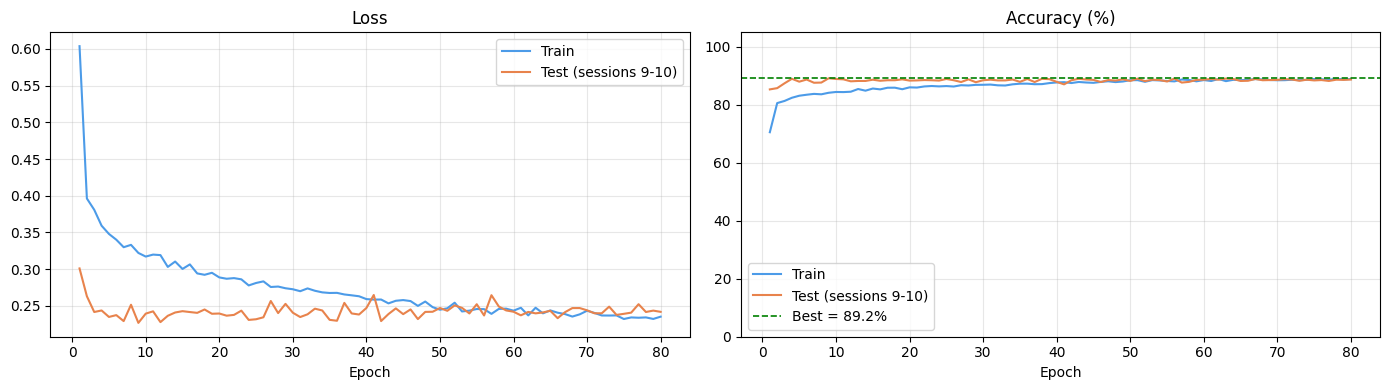

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ep = range(1, EPOCHS + 1)

axes[0].plot(ep, train_losses, label='Train', color='#4C9BE8')
axes[0].plot(ep, test_losses,  label='Test (sessions 9-10)', color='#E8834C')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, [a*100 for a in train_accs], label='Train', color='#4C9BE8')
axes[1].plot(ep, [a*100 for a in test_accs],  label='Test (sessions 9-10)', color='#E8834C')
axes[1].axhline(best_acc*100, color='green', ls='--', lw=1.2,
                label=f'Best = {best_acc:.1%}')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 105); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_v3.png', dpi=100, bbox_inches='tight')
plt.show()

## Step 12 — Confusion matrix

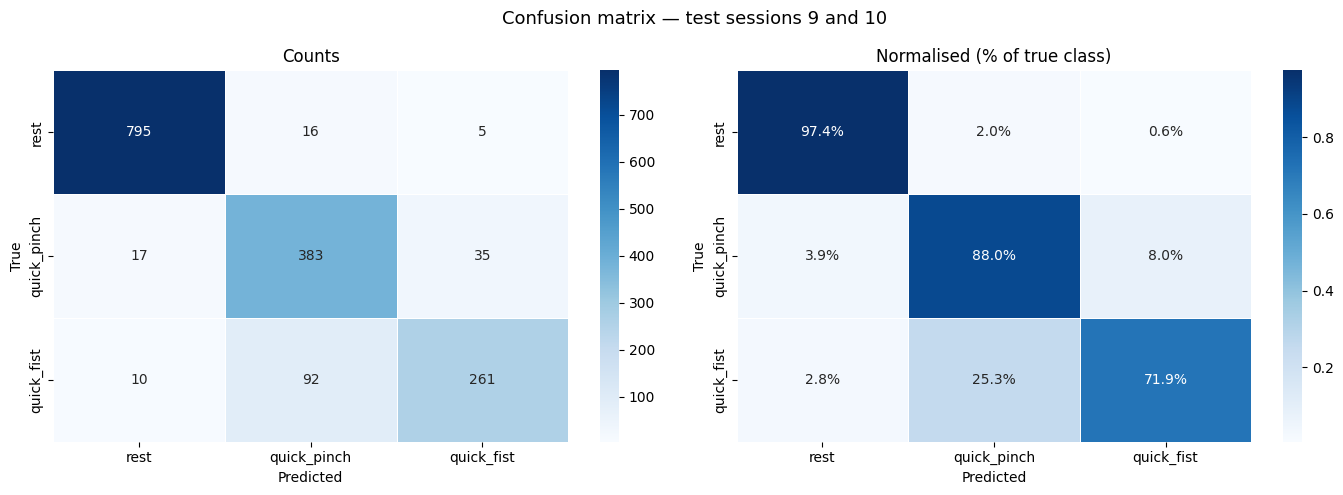


              precision    recall  f1-score   support

        rest       0.97      0.97      0.97       816
 quick_pinch       0.78      0.88      0.83       435
  quick_fist       0.87      0.72      0.79       363

    accuracy                           0.89      1614
   macro avg       0.87      0.86      0.86      1614
weighted avg       0.89      0.89      0.89      1614



In [ ]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).argmax(1).cpu().numpy()

cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0], lw=0.5)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Counts')

sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1], lw=0.5)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title('Normalised (% of true class)')

plt.suptitle('Confusion matrix — test sessions 9 and 10', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix_v3.png', dpi=100, bbox_inches='tight')
plt.show()
print()
print(classification_report(y_test, y_pred, target_names=CLASSES))

## Step 13 — Visualise what the CNN learned

This shows the activations of the first convolutional layer's filters on
a sample window from each class. Filters that activate strongly for one
class but not others are the most discriminative — they've learned the
unique waveform patterns for that gesture.

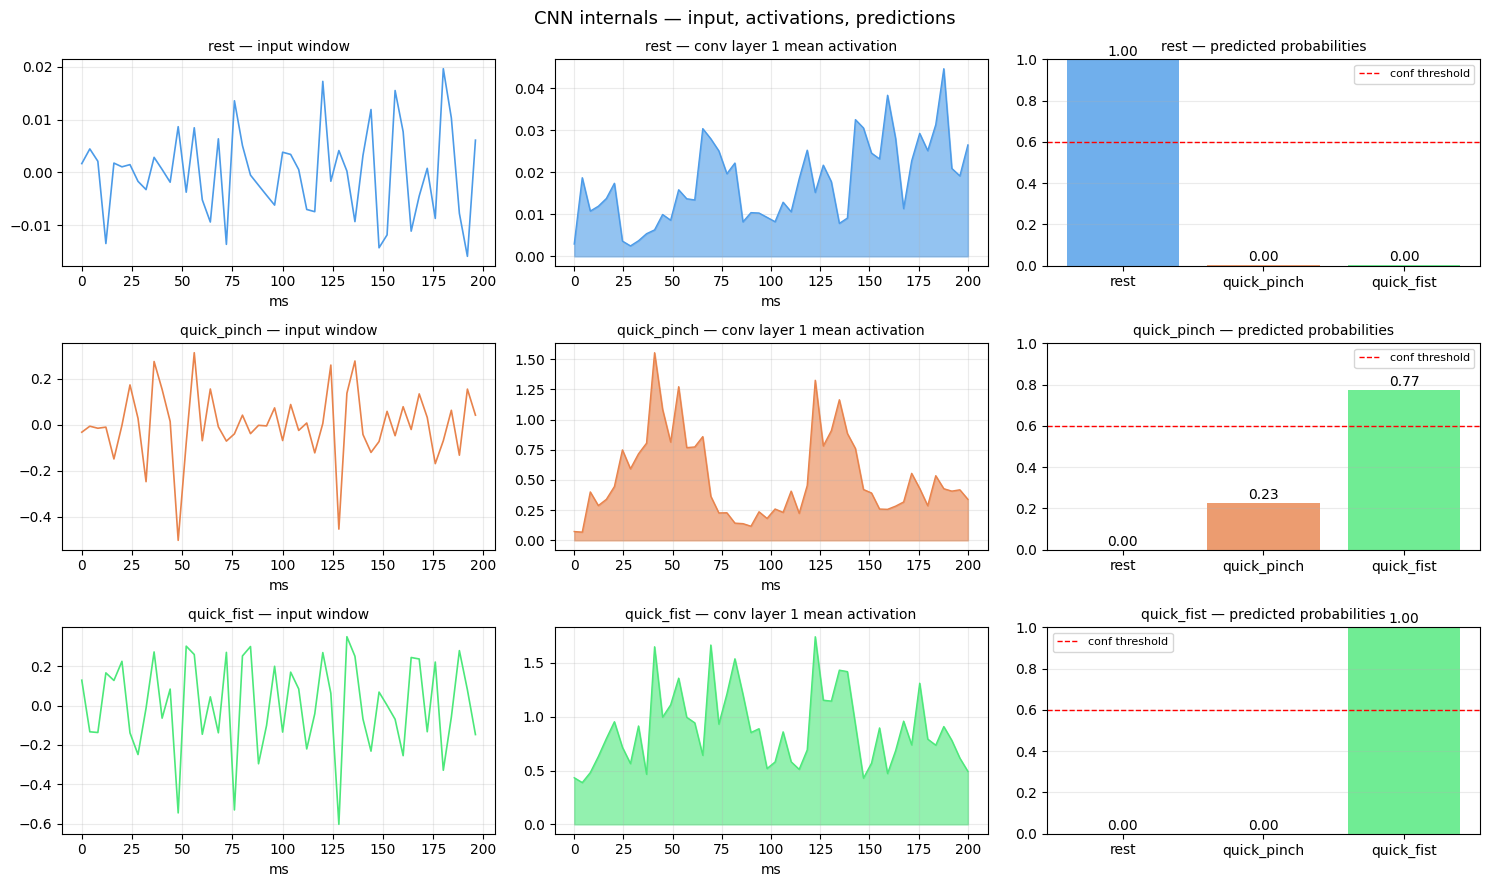

In [ ]:
model.eval()
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
t = np.arange(WINDOW_SIZE) / FS * 1000

for row, label in enumerate(CLASSES):
    cls_i = label_to_idx[label]
    # Pick a representative window (high RMS for gesture, low for rest)
    mask  = y_test == cls_i
    if cls_i == 0:
        idx = np.where(mask)[0][5]   # any rest window
    else:
        rms_vals = [np.sqrt(np.mean(X_test[i]**2)) for i in np.where(mask)[0]]
        idx = np.where(mask)[0][np.argmax(rms_vals)]   # highest RMS

    window  = X_test[idx]
    color   = list(palette.values())[row]

    # Raw window
    axes[row][0].plot(t, window, color=color, lw=1.2)
    axes[row][0].set_title(f'{label} — input window', fontsize=10)
    axes[row][0].set_xlabel('ms'); axes[row][0].grid(True, alpha=0.25)

    # First conv layer activations
    inp = torch.tensor(window[np.newaxis, np.newaxis, :]).to(device)
    with torch.no_grad():
        act1 = model.features[:3](inp).squeeze(0).cpu().numpy()   # (32, 25) after pool
    # Show mean of all 32 filters
    mean_act = act1.mean(axis=0)
    t_act    = np.linspace(0, WINDOW_SIZE/FS*1000, len(mean_act))
    axes[row][1].fill_between(t_act, 0, mean_act, color=color, alpha=0.6)
    axes[row][1].plot(t_act, mean_act, color=color, lw=1.0)
    axes[row][1].set_title(f'{label} — conv layer 1 mean activation', fontsize=10)
    axes[row][1].set_xlabel('ms'); axes[row][1].grid(True, alpha=0.25)

    # Softmax probabilities
    with torch.no_grad():
        logits = model(inp)
        probs  = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    bars = axes[row][2].bar(CLASSES, probs,
                            color=['#4C9BE8','#E8834C','#4CE87A'], alpha=0.8)
    axes[row][2].set_ylim(0, 1)
    axes[row][2].axhline(0.6, color='red', ls='--', lw=1, label='conf threshold')
    axes[row][2].set_title(f'{label} — predicted probabilities', fontsize=10)
    axes[row][2].legend(fontsize=8)
    axes[row][2].grid(True, alpha=0.25, axis='y')
    for bar, p in zip(bars, probs):
        axes[row][2].text(bar.get_x()+bar.get_width()/2, p+0.02, f'{p:.2f}',
                          ha='center', fontsize=10)

plt.suptitle('CNN internals — input, activations, predictions', fontsize=13)
plt.tight_layout()
plt.savefig('cnn_internals.png', dpi=100, bbox_inches='tight')
plt.show()

## Step 14 — Export for ESP32-S3

The CNN weights are exported as C arrays in `model_weights_v3.h`.
No TFLite needed — inference is plain C matrix multiplications and convolutions.

The export includes:
- Filter coefficients (FILTER_B, FILTER_A)
- All conv layer weights and biases (BN folded in)
- All linear layer weights and biases
- Window size and class count defines

In [ ]:
model.eval().cpu()

def fold_bn_into_linear(linear_layer, bn_layer):
    W = linear_layer.weight.data.numpy().copy()
    b = linear_layer.bias.data.numpy().copy()
    gamma = bn_layer.weight.data.numpy()
    beta  = bn_layer.bias.data.numpy()
    mu    = bn_layer.running_mean.numpy()
    var   = bn_layer.running_var.numpy()
    eps   = bn_layer.eps
    scale = gamma / np.sqrt(var + eps)
    return W * scale[:, None], (b - mu) * scale + beta

def fold_bn_into_conv(conv_layer, bn_layer):
    W = conv_layer.weight.data.numpy().copy()   # (out, in, kernel)
    b = conv_layer.bias.data.numpy().copy() if conv_layer.bias is not None \
        else np.zeros(conv_layer.out_channels)
    gamma = bn_layer.weight.data.numpy()
    beta  = bn_layer.bias.data.numpy()
    mu    = bn_layer.running_mean.numpy()
    var   = bn_layer.running_var.numpy()
    eps   = bn_layer.eps
    scale = gamma / np.sqrt(var + eps)
    W_fold = W * scale[:, None, None]
    b_fold = (b - mu) * scale + beta
    return W_fold, b_fold

def arr_to_c(name, arr):
    flat = arr.flatten()
    vals = ', '.join(f'{v:.8f}f' for v in flat)
    return f'static const float {name}[{len(flat)}] = {{\n    {vals}\n}};'

# Extract all layers from model.features (Conv, BN, ReLU, MaxPool, Dropout)
feat_layers = list(model.features.children())
conv_blocks = []
i = 0
while i < len(feat_layers):
    m = feat_layers[i]
    if isinstance(m, nn.Conv1d):
        bn = feat_layers[i+1] if isinstance(feat_layers[i+1], nn.BatchNorm1d) else None
        if bn:
            W, b = fold_bn_into_conv(m, bn)
            i += 2
        else:
            W = m.weight.data.numpy()
            b = m.bias.data.numpy()
            i += 1
        # Find if there's a MaxPool after ReLU
        pool_size = 1
        j = i
        while j < len(feat_layers) and not isinstance(feat_layers[j], nn.Conv1d):
            if isinstance(feat_layers[j], nn.MaxPool1d):
                pool_size = feat_layers[j].kernel_size
            j += 1
        conv_blocks.append({'W': W, 'b': b, 'pool': pool_size,
                             'in_ch': W.shape[1], 'out_ch': W.shape[0], 'kernel': W.shape[2]})
        print(f'Conv block: in={W.shape[1]} out={W.shape[0]} kernel={W.shape[2]} pool={pool_size}')
    i += 1

# Extract classifier layers
clf_layers = list(model.classifier.children())
linear_blocks = []
for m in clf_layers:
    if isinstance(m, nn.Linear):
        W = m.weight.data.numpy()
        b = m.bias.data.numpy()
        linear_blocks.append({'W': W, 'b': b})
        print(f'Linear: in={W.shape[1]} out={W.shape[0]}')

# Build header
lines = [
    '// Auto-generated — EMG training notebook v3 (1D CNN)',
    '// Architecture: 1x50 -> Conv(32,k5) -> Conv(64,k3) -> Conv(64,k3) -> GAP -> FC(32) -> FC(3)',
    f'// Classes: {" | ".join(f"{i}={c}" for i,c in enumerate(CLASSES))}',
    f'// Best test accuracy: {best_acc:.1%}  (tested on sessions 9-10)',
    '#pragma once',
    '#include <stdint.h>',
    '',
    '// ── Filter (20-120 Hz bandpass, 2nd order Butterworth -> 4th order IIR) ──',
    f'static const float FILTER_B[5] = {{{', '.join(f'{v:.8f}f' for v in b_filt)}}};',
    f'static const float FILTER_A[5] = {{{', '.join(f'{v:.8f}f' for v in a_filt)}}};',
    '',
    f'#define NUM_CLASSES    {NUM_CLASSES}',
    f'#define WINDOW_SIZE    {WINDOW_SIZE}',
    f'#define SAMPLE_RATE    {FS}',
    '',
    '// ── Conv layers (BN folded in) ──',
]

for i, cb in enumerate(conv_blocks):
    n = i + 1
    lines.append(f'// Conv{n}: {cb["in_ch"]} in, {cb["out_ch"]} out, kernel={cb["kernel"]}, pool={cb["pool"]}')
    lines.append(f'#define CONV{n}_IN_CH   {cb["in_ch"]}')
    lines.append(f'#define CONV{n}_OUT_CH  {cb["out_ch"]}')
    lines.append(f'#define CONV{n}_KERNEL  {cb["kernel"]}')
    lines.append(f'#define CONV{n}_POOL    {cb["pool"]}')
    lines.append(arr_to_c(f'CONV{n}_W', cb['W']))
    lines.append(arr_to_c(f'CONV{n}_B', cb['b']))
    lines.append('')

lines.append('// ── FC layers ──')
for i, lb in enumerate(linear_blocks):
    n = i + 1
    lines.append(f'// FC{n}: {lb["W"].shape[1]} in, {lb["W"].shape[0]} out')
    lines.append(arr_to_c(f'FC{n}_W', lb['W']))
    lines.append(arr_to_c(f'FC{n}_B', lb['b']))
    lines.append('')

header = '\n'.join(lines)
with open('model_weights_v3.h', 'w') as f:
    f.write(header)
print(f'Saved model_weights_v3.h ({len(header):,} bytes)')

Conv block: in=1 out=32 kernel=5 pool=2
Conv block: in=32 out=64 kernel=3 pool=2
Conv block: in=64 out=64 kernel=3 pool=1
Linear: in=64 out=32
Linear: in=32 out=3
Saved model_weights_v3.h (284,734 bytes)


## Step 15 — Download everything

In [ ]:
from google.colab import files

torch.save(model.state_dict(), 'gesture_model_v3.pth')

outputs = [
    'model_weights_v3.h', 'gesture_model_v3.pth',
    'all_sessions_v3.png', 'cnn_input_windows.png',
    'training_curves_v3.png', 'confusion_matrix_v3.png',
    'cnn_internals.png',
]

with zipfile.ZipFile('emg_results_v3.zip', 'w') as zf:
    for f in outputs:
        if os.path.exists(f):
            zf.write(f)
            print(f'Added: {f}')

files.download('emg_results_v3.zip')
print('Done.')

Added: model_weights_v3.h
Added: gesture_model_v3.pth
Added: all_sessions_v3.png
Added: cnn_input_windows.png
Added: training_curves_v3.png
Added: confusion_matrix_v3.png
Added: cnn_internals.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done.
